In [1]:
# ============================================================
#  Assignment 4 — Common Setup
#  每個組員在自己的 section 前先跑這整塊
# ============================================================

# ---------- 安裝 ----------
!pip install openml scikit-image torch torchvision -q

# ---------- Imports ----------
import os, time
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image

import openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import warnings
warnings.filterwarnings("ignore")

# ---------- 全域設定 ----------
RANDOM_SEED  = 2026
DATASET_ID   = 44238
IMG_SIZE_CNN = 128   # SmallCNN 用
IMG_SIZE_RES = 224   # ResNet / ViT 用

# ---------- 資料載入 ----------
print("Downloading Meta-Album PLK Micro...")
dataset = openml.datasets.get_dataset(
    DATASET_ID,
    download_data=True,
    download_all_files=True,
)
print("Dataset name :", dataset.name)

X_meta, y_meta, _, attr_names = dataset.get_data(
    target=dataset.default_target_attribute,
    dataset_format="dataframe",
)
print("Columns      :", list(X_meta.columns))
print("Samples      :", len(X_meta))
print("Classes      :", y_meta.nunique())

# ---------- 建立 df_images ----------
# 找出 cache 目錄下所有圖片
# dataset.data_file 對圖片資料集為 None，改用 OpenML cache 目錄
cache_dir = Path(openml.config.get_cache_directory()) / "datasets" / str(DATASET_ID)
all_images = (
    list(cache_dir.rglob("*.jpg"))
    + list(cache_dir.rglob("*.png"))
    + list(cache_dir.rglob("*.jpeg"))
)
print(f"Image files found: {len(all_images)}")
assert len(all_images) == 800, f"Expected 800 images, got {len(all_images)}"

# 用 OpenML metadata 取得 authoritative filename→label，避免依賴目錄結構
path_by_stem = {p.stem: str(p) for p in all_images}
records = []
for fname, label in zip(X_meta["FILE_NAME"], y_meta):
    stem = Path(fname).stem
    if stem in path_by_stem:
        records.append({"path": path_by_stem[stem], "label": str(label)})
assert len(records) == 800, f"Matched {len(records)}/800 images to metadata"

df_images = pd.DataFrame(records)
print("\nClass distribution:")
print(df_images["label"].value_counts().sort_index().to_string())

# ---------- Label Encoding ----------
le = LabelEncoder()
df_images["label_enc"] = le.fit_transform(df_images["label"])
NUM_CLASSES = len(le.classes_)
print(f"\nNum classes : {NUM_CLASSES}")
print(f"Classes     : {list(le.classes_)}")

# ---------- 60 / 20 / 20 Stratified Split ----------
train_df, temp_df = train_test_split(
    df_images,
    test_size=0.40,
    stratify=df_images["label"],
    random_state=RANDOM_SEED,
)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=RANDOM_SEED,
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"\nTrain: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}")
assert (train_df["label"].value_counts() == 24).all(), "train split mismatch"
assert (val_df["label"].value_counts()   ==  8).all(), "val split mismatch"
assert (test_df["label"].value_counts()  ==  8).all(), "test split mismatch"
print("Split check passed ✓")

# ---------- 通用圖片載入（Classical ML 用）----------
def load_image_flat(path, size=(128, 128), grayscale=True):
    """載入單張圖片，回傳 flatten 的 float32 array，pixel 值 /255"""
    mode = "L" if grayscale else "RGB"
    img  = Image.open(path).convert(mode).resize(size)
    return np.asarray(img, dtype=np.float32).flatten() / 255.0


def make_pixel_features(df, size=(128, 128), grayscale=True):
    """整批 df 轉成 pixel feature matrix"""
    features = np.stack([
        load_image_flat(row["path"], size, grayscale)
        for _, row in df.iterrows()
    ])
    labels = le.transform(df["label"].values)
    return features, labels


# ---------- PyTorch Dataset ----------
class PlanktonDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df        = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        img   = Image.open(row["path"]).convert("RGB")
        label = int(row["label_enc"])
        if self.transform:
            img = self.transform(img)
        return img, label


# ---------- Transforms ----------
# CNN（從頭訓練）
cnn_train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE_CNN, IMG_SIZE_CNN)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])
cnn_eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE_CNN, IMG_SIZE_CNN)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

# ResNet18 / ViT（ImageNet 正規化）
resnet_train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE_RES, IMG_SIZE_RES)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])
resnet_eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE_RES, IMG_SIZE_RES)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# ---------- 通用 DataLoader 工廠 ----------
def make_loaders(train_tf, eval_tf, batch_train=32, batch_eval=64):
    train_ds = PlanktonDataset(train_df, transform=train_tf)
    val_ds   = PlanktonDataset(val_df,   transform=eval_tf)
    test_ds  = PlanktonDataset(test_df,  transform=eval_tf)
    return (
        DataLoader(train_ds, batch_size=batch_train, shuffle=True,  num_workers=0, pin_memory=True),
        DataLoader(val_ds,   batch_size=batch_eval,  shuffle=False, num_workers=0, pin_memory=True),
        DataLoader(test_ds,  batch_size=batch_eval,  shuffle=False, num_workers=0, pin_memory=True),
    )

# ---------- Device ----------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nDevice: {device}")

# ---------- 通用 evaluate 函數（PyTorch）----------
def evaluate(model, loader, criterion):
    """回傳 (avg_loss, accuracy, macro_f1, all_preds, all_labels)"""
    model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    with torch.no_grad():
        for x, y_batch in loader:
            x, y_batch = x.to(device), y_batch.to(device)
            logits = model(x)
            loss   = criterion(logits, y_batch)
            total_loss += loss.item() * x.size(0)
            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())
    avg_loss = total_loss / len(loader.dataset)
    acc      = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    return avg_loss, acc, macro_f1, all_preds, all_labels


# ---------- 通用訓練 Loop ----------
def train_model(model, train_loader, val_loader,
                epochs=20, lr=1e-3, weight_decay=1e-4):
    """
    回傳 history dict：
      {"train_loss", "val_loss", "train_acc", "val_acc"}
    以及訓練秒數。
    """
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=weight_decay,
    )
    history = {"train_loss": [], "val_loss": [],
               "train_acc": [],  "val_acc": []}
    t0 = time.time()

    for epoch in range(1, epochs + 1):
        model.train()
        for x, y_batch in train_loader:
            x, y_batch = x.to(device), y_batch.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x), y_batch)
            loss.backward()
            optimizer.step()

        tr_loss, tr_acc, _, _, _ = evaluate(model, train_loader, criterion)
        vl_loss, vl_acc, _, _, _ = evaluate(model, val_loader,   criterion)
        history["train_loss"].append(tr_loss)
        history["val_loss"].append(vl_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(vl_acc)
        print(f"Epoch {epoch:02d}/{epochs}  "
              f"train_loss={tr_loss:.4f}  val_loss={vl_loss:.4f}  "
              f"train_acc={tr_acc:.4f}  val_acc={vl_acc:.4f}")

    elapsed = time.time() - t0
    print(f"Training time: {elapsed:.1f}s  ({elapsed/60:.1f} min)")
    return history, elapsed


# ---------- Learning Curve 畫圖 ----------
def plot_learning_curves(history, model_name="Model"):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history["train_loss"], label="Train")
    axes[0].plot(history["val_loss"],   label="Val")
    axes[0].set_title(f"{model_name} — Loss")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(history["train_acc"], label="Train")
    axes[1].plot(history["val_acc"],   label="Val")
    axes[1].set_title(f"{model_name} — Accuracy")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    plt.suptitle(model_name)
    plt.tight_layout()
    plt.show()


# ---------- Confusion Matrix ----------
def plot_cm(y_true, y_pred, model_name="Model"):
    cm   = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=le.classes_)
    fig, ax = plt.subplots(figsize=(10, 10))
    disp.plot(ax=ax, colorbar=False, xticks_rotation=90)
    ax.set_title(f"Confusion Matrix — {model_name}")
    plt.tight_layout()
    plt.show()


# ============================================================
#  以下各組員貼上自己的模型定義 + 呼叫 train_model / evaluate
#
#  組員1（Model A / B）：直接用 make_pixel_features()
#                       或 make_hog_features() 接 sklearn
#
#  組員2（Model C / D）：呼叫 make_loaders(cnn_train_tf, cnn_eval_tf)
#                       或 make_loaders(resnet_train_tf, resnet_eval_tf)
#                       再呼叫 train_model(model, ...) + plot_learning_curves(...)
#
#  組員3（Model E / F）：同上，替換 model 為 ViT/DeiT
# ============================================================

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.4/160.4 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.8/93.8 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 30.6 MB/s eta 0:00:00
Dataset name : Meta_Album_PLK_Micro
Columns      : ['FILE_NAME', 'SUPER_CATEGORY']
Samples      : 800
Classes      : 20
Image files found: 800

Class distribution:
label
Chaetoceros                   40
Chrysochromulina              40
Dinophysis                    40
Emiliania_huxleyi             40
Ephemera                      40
Leptocylindrus                40
Mesodinium_sp                 40
Prorocentrum                  40
Pseudochattonella_farcimen    40
Pseudonitzschia               40
Rhizosolenia                  40
Skeletonema                   40
Strombidium_inclinatum        40
Strombidium_oculatum          40
Strombidium_wulffi            40
Thalassiosira_dirty           40
Tintinnid                 

Building raw-pixel features...
Raw feature shape: (480, 16384)

=== Model A: Raw Pixels + Logistic Regression ===
Training time : 41.1s
Runtime       : GPU

Validation
Accuracy : 0.4375
Macro-F1 : 0.4149

Test
Accuracy : 0.3937
Macro-F1 : 0.3874

Classification Report
                            precision    recall  f1-score   support

               Chaetoceros       0.25      0.25      0.25         8
          Chrysochromulina       0.25      0.38      0.30         8
                Dinophysis       0.14      0.12      0.13         8
         Emiliania_huxleyi       0.71      0.62      0.67         8
                  Ephemera       0.75      0.75      0.75         8
            Leptocylindrus       0.33      0.38      0.35         8
             Mesodinium_sp       0.12      0.12      0.12         8
              Prorocentrum       0.44      0.50      0.47         8
Pseudochattonella_farcimen       0.64      0.88      0.74         8
           Pseudonitzschia       0.38      0.38   

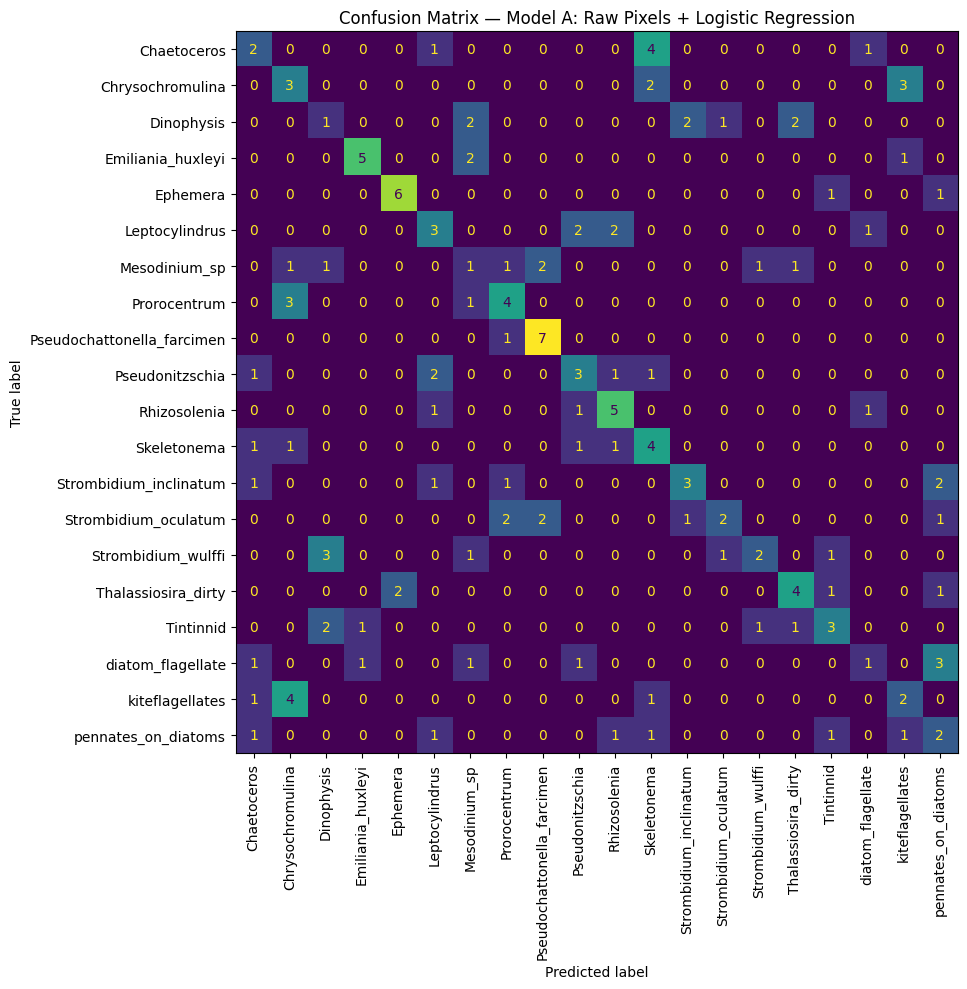

In [2]:
# ============================================================
#  Model A — Raw Pixels + Logistic Regression
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# ── Raw pixel 特徵提取 ──
def make_raw_pixel_features(df, size=(128, 128)):
    features, labels = [], []

    for _, row in df.iterrows():
        img = (
            Image.open(row["path"])
            .convert("L")                  # grayscale
            .resize(size)
        )

        arr = np.asarray(img, dtype=np.float32) / 255.0

        # flatten 成一維向量
        features.append(arr.flatten())
        labels.append(row["label"])

    return np.stack(features), le.transform(np.array(labels))


print("Building raw-pixel features...")

X_train_raw, y_train_enc = make_raw_pixel_features(train_df)
X_val_raw,   y_val_enc   = make_raw_pixel_features(val_df)
X_test_raw,  y_test_enc  = make_raw_pixel_features(test_df)

print(f"Raw feature shape: {X_train_raw.shape}")

# ============================================================
#  Logistic Regression
# ============================================================

t0 = time.time()

model_a = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=3000,
        random_state=RANDOM_SEED,
        n_jobs=-1,
    ))
])

model_a.fit(X_train_raw, y_train_enc)

time_a = time.time() - t0

# ============================================================
#  Evaluation
# ============================================================

pred_val  = model_a.predict(X_val_raw)
pred_test = model_a.predict(X_test_raw)

val_acc = accuracy_score(y_val_enc, pred_val)
val_f1  = f1_score(y_val_enc, pred_val, average="macro")

test_acc = accuracy_score(y_test_enc, pred_test)
test_f1  = f1_score(y_test_enc, pred_test, average="macro")

print("\n=== Model A: Raw Pixels + Logistic Regression ===")
print(f"Training time : {time_a:.1f}s")
print(f"Runtime       : {'GPU' if torch.cuda.is_available() else 'CPU'}")

print(f"\nValidation")
print(f"Accuracy : {val_acc:.4f}")
print(f"Macro-F1 : {val_f1:.4f}")

print(f"\nTest")
print(f"Accuracy : {test_acc:.4f}")
print(f"Macro-F1 : {test_f1:.4f}")

print("\nClassification Report")
print(classification_report(
    y_test_enc,
    pred_test,
    target_names=le.classes_,
    zero_division=0
))

# ============================================================
#  Confusion Matrix
# ============================================================

plot_cm(y_test_enc, pred_test,
        "Model A: Raw Pixels + Logistic Regression")

Training time: 53.6s  
Runtime: CPU

In [ ]:
# ============================================================
# Model D : Pretrained ResNet18 Feature Extractor
# ============================================================

from torchvision import models
import torch.nn as nn

# ---------- DataLoader ----------
train_loader, val_loader, test_loader = make_loaders(
    resnet_train_tf,
    resnet_eval_tf
)

# ---------- ResNet18 ----------
resnet = models.resnet18(
    weights=models.ResNet18_Weights.DEFAULT
)

# Freeze backbone
for param in resnet.parameters():
    param.requires_grad = False

# Replace classifier head
in_features = resnet.fc.in_features
resnet.fc = nn.Linear(in_features, NUM_CLASSES)

resnet = resnet.to(device)

# ---------- Trainable Parameters ----------
trainable_params = sum(
    p.numel() for p in resnet.parameters()
    if p.requires_grad
)

total_params = sum(
    p.numel() for p in resnet.parameters()
)

print(f"Total Parameters     : {total_params:,}")
print(f"Trainable Parameters : {trainable_params:,}")

# ---------- Training ----------
history_resnet, resnet_train_time = train_model(
    resnet,
    train_loader,
    val_loader,
    epochs=20,
    lr=1e-3,
    weight_decay=1e-4
)

# ---------- Learning Curves ----------
plot_learning_curves(
    history_resnet,
    "ResNet18 Feature Extractor"
)

# ============================================================
# Final Test Evaluation
# ============================================================

criterion = nn.CrossEntropyLoss()

test_loss, test_acc, test_f1, preds, labels = evaluate(
    resnet,
    test_loader,
    criterion
)

print("\n===== ResNet18 Test Result =====")
print(f"Test Accuracy : {test_acc:.4f}")
print(f"Test Macro-F1 : {test_f1:.4f}")
print(f"Training Time : {resnet_train_time:.1f} sec")
print(f"Runtime Type  : {device}")

print(
    classification_report(
        labels,
        preds,
        target_names=le.classes_,
        digits=4,
        zero_division=0
    )
)

plot_cm(
    labels,
    preds,
    "ResNet18 Feature Extractor"
)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 73.3MB/s]


  Model D: Pretrained ResNet18 Feature Extractor
  Total params     : 11,186,772
  Trainable params :     10,260  ← fc head only
  Frozen params    : 11,176,512  ← backbone
  Input size       : 224 × 224 (ImageNet standard)
  Normalization    : ImageNet mean/std
  Backbone frozen  : True
  Head             : Dropout(0.3) → Linear(512, 20)
Train batches : 15  (~480 images)
Val   batches : 3  (~160 images)
Test  batches : 3  (~160 images)
Training ResNet18 head for 20 epochs (lr=0.001, wd=0.0001) on cuda ...
-----------------------------------------------------------------
Epoch 01/20  train_loss=2.8822  val_loss=2.9202  train_acc=0.1208  val_acc=0.1187
Epoch 02/20  train_loss=2.5244  val_loss=2.5533  train_acc=0.2875  val_acc=0.2875
Epoch 03/20  train_loss=2.2661  val_loss=2.3028  train_acc=0.4125  val_acc=0.3812
Epoch 04/20  train_loss=2.0190  val_loss=2.1437  train_acc=0.4875  val_acc=0.4250
Epoch 05/20  train_loss=1.8167  val_loss=1.9487  train_acc=0.5667  val_acc=0.4813
Epoch 06/20 

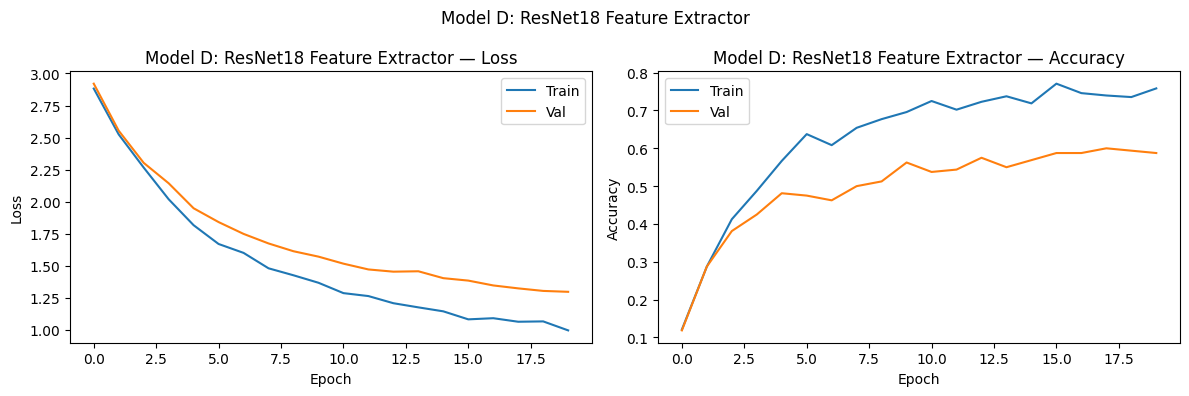


  Model D: ResNet18 — Final Results
  Val  Acc  = 0.5875   Macro-F1 = 0.5572
  Test Acc  = 0.5750   Macro-F1 = 0.5524
  Trainable params : 10,260
  Training time    : 77.8s (1.3 min)
  Runtime type     : GPU

Per-class report (test set):
                            precision    recall  f1-score   support

               Chaetoceros       0.67      0.75      0.71         8
          Chrysochromulina       0.53      1.00      0.70         8
                Dinophysis       0.50      0.25      0.33         8
         Emiliania_huxleyi       0.86      0.75      0.80         8
                  Ephemera       0.67      1.00      0.80         8
            Leptocylindrus       0.42      0.62      0.50         8
             Mesodinium_sp       0.67      0.50      0.57         8
              Prorocentrum       0.60      0.38      0.46         8
Pseudochattonella_farcimen       0.86      0.75      0.80         8
           Pseudonitzschia       0.00      0.00      0.00         8
            

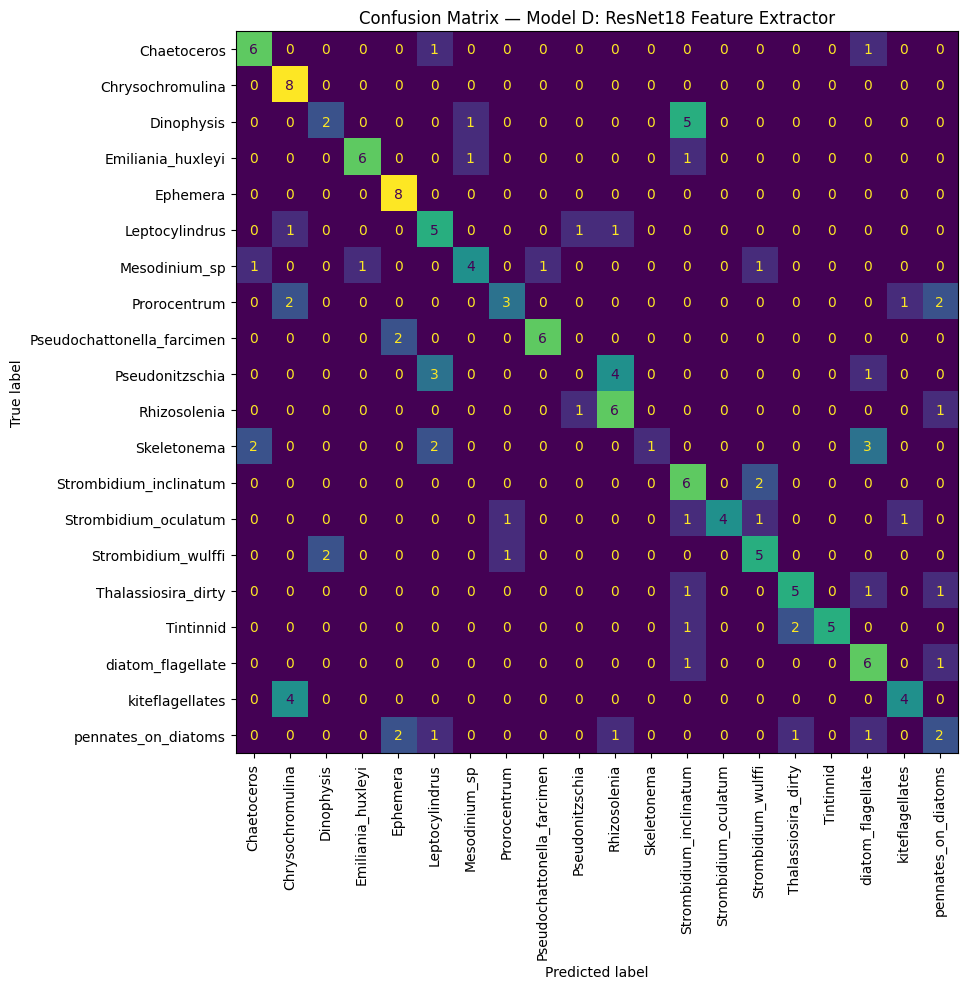

In [4]:
import time
import torch
import torch.nn as nn
from torchvision import models
from sklearn.metrics import classification_report

# ============================================================
#  Model D — Pretrained ResNet18 Feature Extractor
# ============================================================

# ── 1. 載入預訓練權重，凍結整個 backbone ──────────────────────
resnet18 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# 凍結所有層的梯度（backbone 完全不更新）
for param in resnet18.parameters():
    param.requires_grad = False

# ── 2. 替換 classifier head（fc 層），只有這層是可訓練的 ───────
in_features = resnet18.fc.in_features   # ResNet18 = 512
resnet18.fc = nn.Sequential(
    nn.Dropout(p=0.3),                  # 輕微正則化，避免 head 在小資料集過擬合
    nn.Linear(in_features, NUM_CLASSES),
)
resnet18 = resnet18.to(device)

# ── 3. 確認可訓練參數數量 ──────────────────────────────────────
total_params     = sum(p.numel() for p in resnet18.parameters())
trainable_params = sum(p.numel() for p in resnet18.parameters() if p.requires_grad)
frozen_params    = total_params - trainable_params

print("=" * 55)
print("  Model D: Pretrained ResNet18 Feature Extractor")
print("=" * 55)
print(f"  Total params     : {total_params:>10,}")
print(f"  Trainable params : {trainable_params:>10,}  ← fc head only")
print(f"  Frozen params    : {frozen_params:>10,}  ← backbone")
print(f"  Input size       : 224 × 224 (ImageNet standard)")
print(f"  Normalization    : ImageNet mean/std")
print(f"  Backbone frozen  : True")
print(f"  Head             : Dropout(0.3) → Linear({in_features}, {NUM_CLASSES})")
print("=" * 55)

# ── 4. 建立 DataLoader（使用 resnet_train_tf / resnet_eval_tf）──
#
# resnet_train_tf：Resize(224) + RandomHFlip + RandomRotation(10)
#                  + ToTensor + Normalize(ImageNet)
# resnet_eval_tf ：Resize(224) + ToTensor + Normalize(ImageNet)
# （兩個 transform 皆由 Common Setup 定義）

train_loader_res, val_loader_res, test_loader_res = make_loaders(
    resnet_train_tf,
    resnet_eval_tf,
    batch_train=32,
    batch_eval=64,
)
print(f"Train batches : {len(train_loader_res)}  "
      f"(~{len(train_loader_res.dataset)} images)")
print(f"Val   batches : {len(val_loader_res)}  "
      f"(~{len(val_loader_res.dataset)} images)")
print(f"Test  batches : {len(test_loader_res)}  "
      f"(~{len(test_loader_res.dataset)} images)")

# ── 5. 訓練（只更新 fc head）────────────────────────────────────
#
# train_model() 內部使用 Adam + CrossEntropyLoss，
# 並自動過濾 requires_grad=False 的參數，故只會更新 fc head。
#
# 最多 20 epochs（作業規定 ResNet18 feature extractor ≤ 20 epochs）

EPOCHS_RES = 20
LR_RES     = 1e-3
WD_RES     = 1e-4

print(f"Training ResNet18 head for {EPOCHS_RES} epochs "
      f"(lr={LR_RES}, wd={WD_RES}) on {device} ...")
print("-" * 65)

history_res, elapsed_res = train_model(
    resnet18,
    train_loader_res,
    val_loader_res,
    epochs=EPOCHS_RES,
    lr=LR_RES,
    weight_decay=WD_RES,
)

print("-" * 65)
print(f"Training time : {elapsed_res:.1f}s  ({elapsed_res/60:.1f} min)")
print(f"Runtime type  : {'GPU' if torch.cuda.is_available() else 'CPU'}")

# ── 6. Learning Curves ───────────────────────────────────────────
plot_learning_curves(history_res, "Model D: ResNet18 Feature Extractor")

# ── 7. 最終評估 ──────────────────────────────────────────────────
criterion_res = nn.CrossEntropyLoss()

_, val_acc_res,  val_f1_res,  _, _              = evaluate(resnet18, val_loader_res,  criterion_res)
_, test_acc_res, test_f1_res, preds_res, labs_res = evaluate(resnet18, test_loader_res, criterion_res)

print("\n" + "=" * 55)
print("  Model D: ResNet18 — Final Results")
print("=" * 55)
print(f"  Val  Acc  = {val_acc_res:.4f}   Macro-F1 = {val_f1_res:.4f}")
print(f"  Test Acc  = {test_acc_res:.4f}   Macro-F1 = {test_f1_res:.4f}")
print(f"  Trainable params : {trainable_params:,}")
print(f"  Training time    : {elapsed_res:.1f}s ({elapsed_res/60:.1f} min)")
print(f"  Runtime type     : {'GPU' if torch.cuda.is_available() else 'CPU'}")
print("=" * 55)

print("\nPer-class report (test set):")
print(classification_report(
    labs_res, preds_res,
    target_names=le.classes_,
    zero_division=0,
))

# ── 8. Confusion Matrix ──────────────────────────────────────────
plot_cm(labs_res, preds_res, "Model D: ResNet18 Feature Extractor")

